# AA-UTE 2026

## P1 - Fundamentos y patrones de series temporales

En P0 repasamos Python, pandas y matplotlib. En este práctico usamos esas herramientas para mirar una serie temporal y descomponerla

Dataset: serie horaria sintética de demanda eléctrica con convención `unique_id`, `ds`, `y`.

Al finalizar este práctico se espera que puedas:

- validar estructura temporal básica de una serie;
- reconocer tendencia, estacionalidad, ruido y outliers;
- comparar escalas de visualización;
- interpretar resampling y rolling windows;



### Trabajo a realizar

Usar **# COMPLETAR**, **# EXPERIMENTAR**, **# DISCUTIR** y **# RESPONDER** como guía. Esta versión mantiene la misma estructura del notebook base y agrega código completo y respuestas esperadas.


## Parte 1 - Preámbulo

Importamos las librerías que se usan en el práctico y fijamos una semilla para que los resultados sean reproducibles.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Nixtla
from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
from statsforecast.models import MSTL 

SEED = 42
rng = np.random.default_rng(SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### RESPONDER

1. ¿Por qué fijamos una semilla?

Respuesta: para que la aleatoriedad sea siempre la misma



## Parte 2 - Carga o generación del dataset

Construimos una serie sintética pequeña para poder trabajar sin descargas externas y con patrones controlados.


In [4]:
def generar_demanda_sintetica(seed=42, periods=24 * 90, start="2026-01-01"):
    """Genera una serie horaria sintética de demanda eléctrica.

    Devuelve columnas unique_id, ds, y. La señal incluye tendencia suave,
    patrón diario, patrón semanal, ruido, outliers y días especiales.
    """
    rng_local = np.random.default_rng(seed)

    # Crear el rango horario.
    ds = pd.date_range(start=start, periods=periods, freq="h")
    step = np.arange(periods)
    hour = ds.hour.to_numpy()
    dayofweek = ds.dayofweek.to_numpy()

    # Definir componentes de la señal.
    trend = 0.035 * step
    daily_pattern = 180 * np.sin(2 * np.pi * (hour - 7) / 24) + 70 * np.sin(4 * np.pi * (hour - 15) / 24)
    weekly_pattern = np.where(dayofweek < 5, 90, -120) + 35 * np.cos(2 * np.pi * dayofweek / 7)
    noise = rng_local.normal(0, 35, periods)

    y = 1200 + trend + daily_pattern + weekly_pattern + noise

    # Código base: días especiales y outliers puntuales.
    for special_day in pd.to_datetime(["2026-01-18", "2026-02-12", "2026-03-03"]):
        y[ds.normalize() == special_day] -= 170

    outlier_positions = rng_local.choice(periods, size=8, replace=False)
    outlier_sign = rng_local.choice([-1, 1], size=len(outlier_positions))
    y[outlier_positions] += outlier_sign * rng_local.uniform(180, 320, size=len(outlier_positions))

    # Devolver el DataFrame con unique_id, ds, y.
    return pd.DataFrame({"unique_id": "demanda_sintetica", "ds": ds, "y": y.round(2)})



### DISCUTIR

En el código de la función que genera la serie sintética,

1. ¿Qué representa cada componente?
2. ¿Qué patrones esperarías ver?
3. ¿Qué limitaciones tiene una serie sintética?


Respuestas  
y = 1200 + trend + daily_pattern + weekly_pattern + noise
  
trend = la tendencia es la variacion que va a tener la serie sin contar la estacionalidad ni los ciclos ni el ruido
daily_pattern = patron diario es la forma de variacion que se repite dia a dia
weekly_pattern = patron semanal es la forma de variacon que se repite semana a semana
noise = ruido es lo que queda: valor de la serie menos la tendencia, la estacionalidad y los patrones diarios y semanales
    

      


      


### Creación de los datos

In [9]:

df = generar_demanda_sintetica(seed=SEED)
df.head()

,unique_id,ds,y
0,demanda_sintetica,2026-01-01 00:00:00,1025.26
1,demanda_sintetica,2026-01-01 01:00:00,981.48
2,demanda_sintetica,2026-01-01 02:00:00,1075.94
3,demanda_sintetica,2026-01-01 03:00:00,1135.61
4,demanda_sintetica,2026-01-01 04:00:00,1098.04


In [10]:
print(df.shape)
df.tail()

(2160, 3)


,unique_id,ds,y
2155,demanda_sintetica,2026-03-31 19:00:00,1468.90
2156,demanda_sintetica,2026-03-31 20:00:00,1387.33
2157,demanda_sintetica,2026-03-31 21:00:00,1512.33
2158,demanda_sintetica,2026-03-31 22:00:00,1248.78
2159,demanda_sintetica,2026-03-31 23:00:00,1144.85


## Parte 3 - Visualización de la serie

Miramos la misma serie en distintas escalas para distinguir tendencia, estacionalidad y valores atípicos.


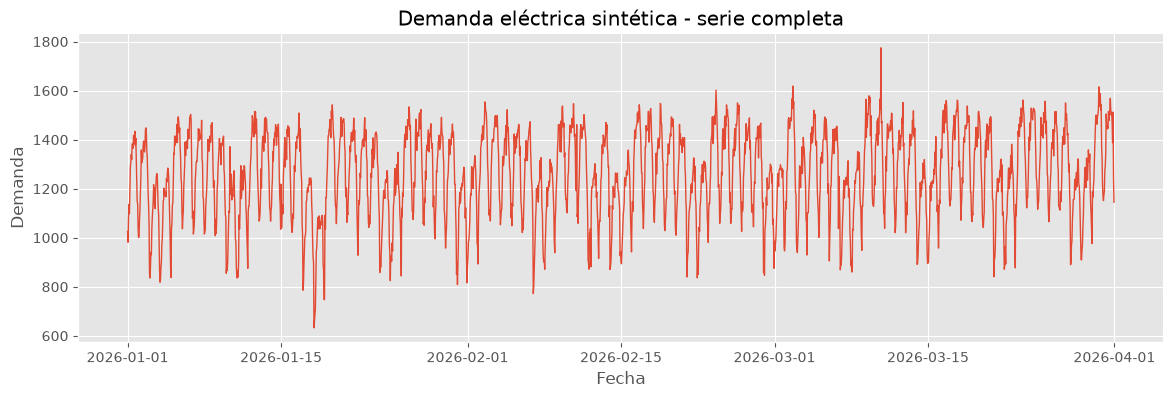

In [11]:
# Serie completa.
plt.figure(figsize=(14, 4))
plt.plot(df["ds"], df["y"], linewidth=1)
plt.title("Demanda eléctrica sintética - serie completa")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.show()

#COMPLETAR Repetir el plot pero usando la funcion plot_series

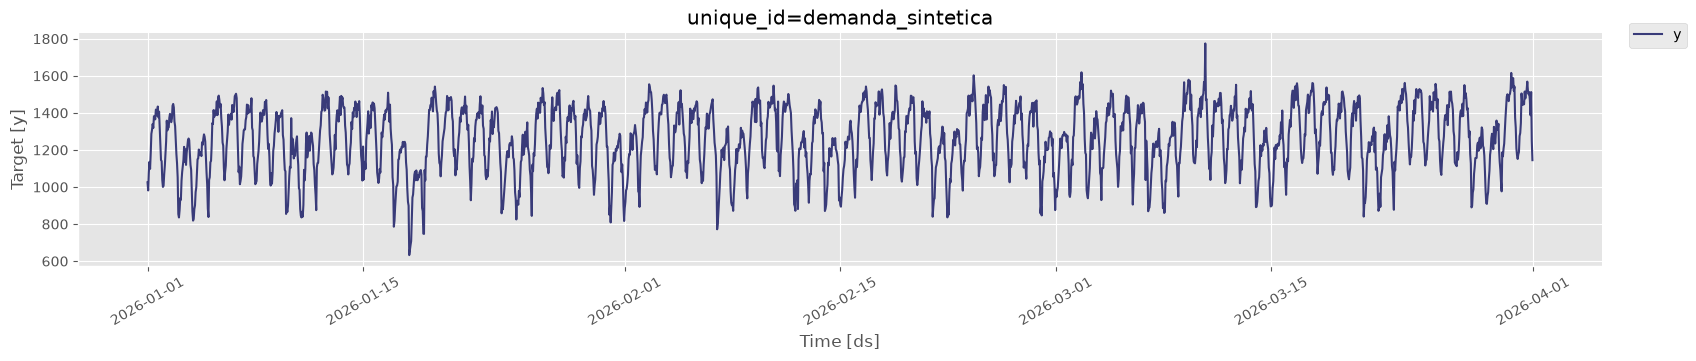

In [13]:
# Repetir el plot pero usando la función plot_series de Nixtla.
# COMPLETAR


# Nixtla
StatsForecast.plot(df)




### Ver distintos intervalos

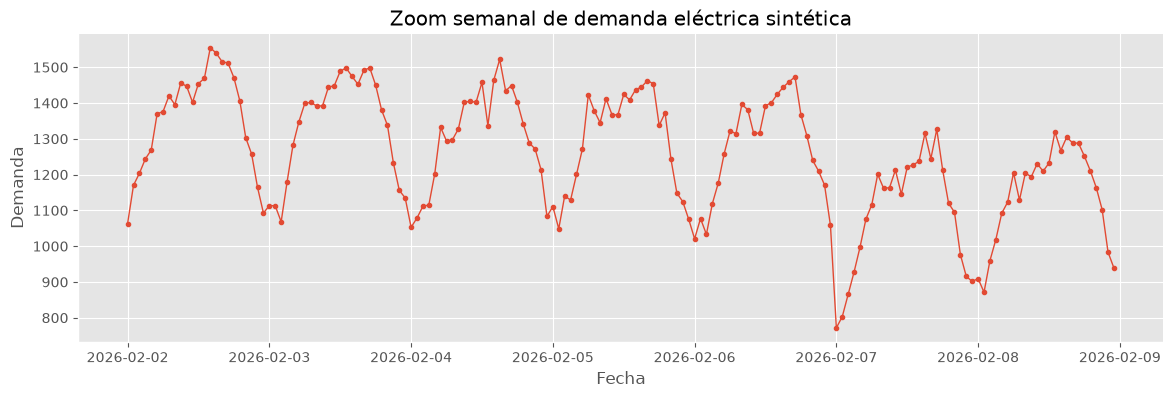

In [14]:
# Zoom semanal.
semana = df[(df["ds"] >= "2026-02-02") & (df["ds"] < "2026-02-09")]
plt.figure(figsize=(14, 4))
# >>> COMPLETAR: graficar la semana filtrada.
plt.plot(semana["ds"], semana["y"], marker=".", linewidth=1)
plt.title("Zoom semanal de demanda eléctrica sintética")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.show()

#COMPLETAR  Repetir lo anterior pero para dos días

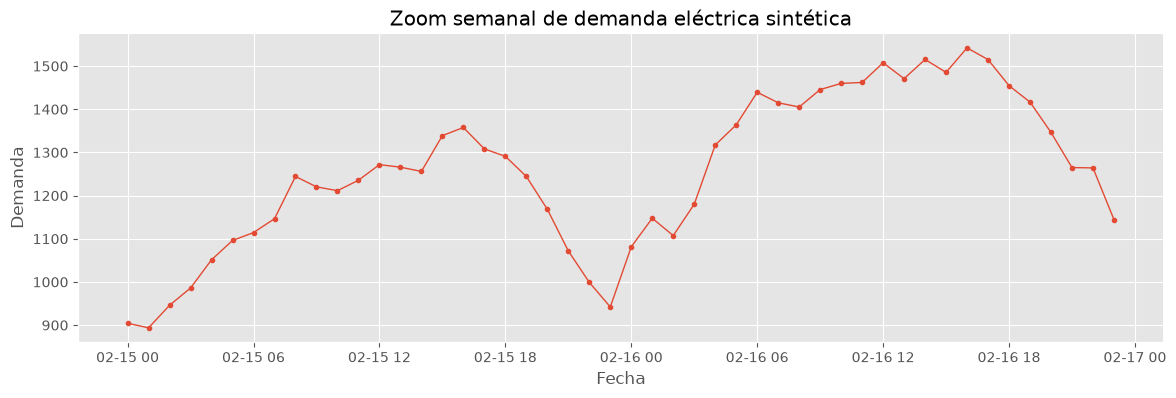

In [18]:
# Zoom de dos días.
# COMPLETAR

# Zoom semanal.
semana = df[(df["ds"] >= "2026-02-15") & (df["ds"] < "2026-02-17")]
plt.figure(figsize=(14, 4))
# >>> COMPLETAR: graficar la semana filtrada.
plt.plot(semana["ds"], semana["y"], marker=".", linewidth=1)
plt.title("Zoom semanal de demanda eléctrica sintética")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.show()


### Perfiles de las distintas semanas

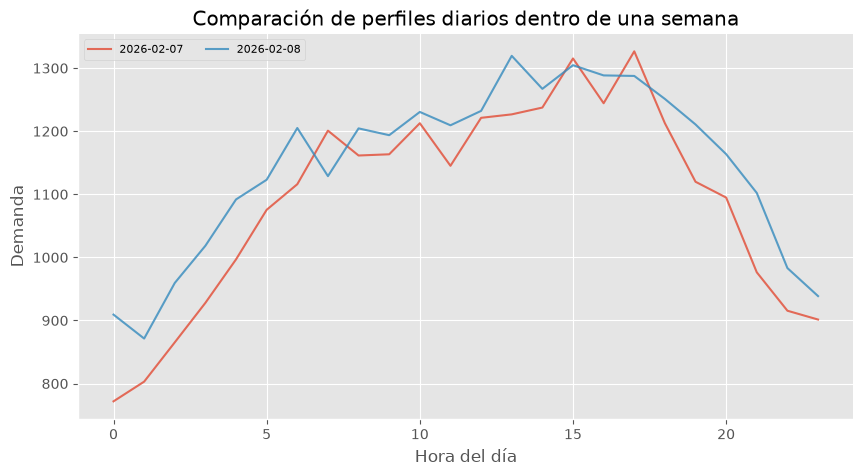

In [16]:
perfiles = semana.copy()
perfiles["fecha"] = perfiles["ds"].dt.date
perfiles["hora"] = perfiles["ds"].dt.hour
plt.figure(figsize=(10, 5))
for fecha, grupo in perfiles.groupby("fecha"):
    plt.plot(grupo["hora"], grupo["y"], alpha=0.8, label=str(fecha))
plt.title("Comparación de perfiles diarios dentro de una semana")
plt.xlabel("Hora del día")
plt.ylabel("Demanda")
plt.legend(ncol=2, fontsize=8)
plt.show()

### DISCUTIR

1. ¿Hay tendencia?
2. ¿Se observa estacionalidad diaria y semanal?
3. ¿Qué escala temporal muestra mejor cada patrón?
4. ¿Hay outliers visibles?

**Respuestas**
  
    
 1 no se observa en los cortes semanales o diarios pero si en la grafica general

 2 si la diaria se parece a una gausiana y la semanal disminuye los dos ultimos dias

 3 a mayor periodo mayor escala
 
 4 en la general se ven     
        
          
            
              
                
                
    



     
      
       
         


## Parte 4 - Resampling y agregación temporal

Agregamos la serie horaria a nivel diario para ver cómo cambia la información disponible.


In [19]:
serie_horaria = df.set_index("ds")["y"].asfreq("h")

# >>> COMPLETAR: calcular agregaciones diarias.
diario_promedio = serie_horaria.resample("D").mean()
diario_maximo =   serie_horaria.resample("D").max()
diario_minimo =   serie_horaria.resample("D").min()

resumen_diario = pd.DataFrame({"promedio": diario_promedio, "maximo": diario_maximo, "minimo": diario_minimo})
resumen_diario.head()

,promedio,maximo,minimo
ds,,,
2026-01-01,1258.203333,1434.21,981.48
2026-01-02,1265.936667,1448.16,1000.45
2026-01-03,1071.064583,1261.62,818.53
2026-01-04,1099.202083,1284.01,828.29
2026-01-05,1321.402083,1493.09,1038.20


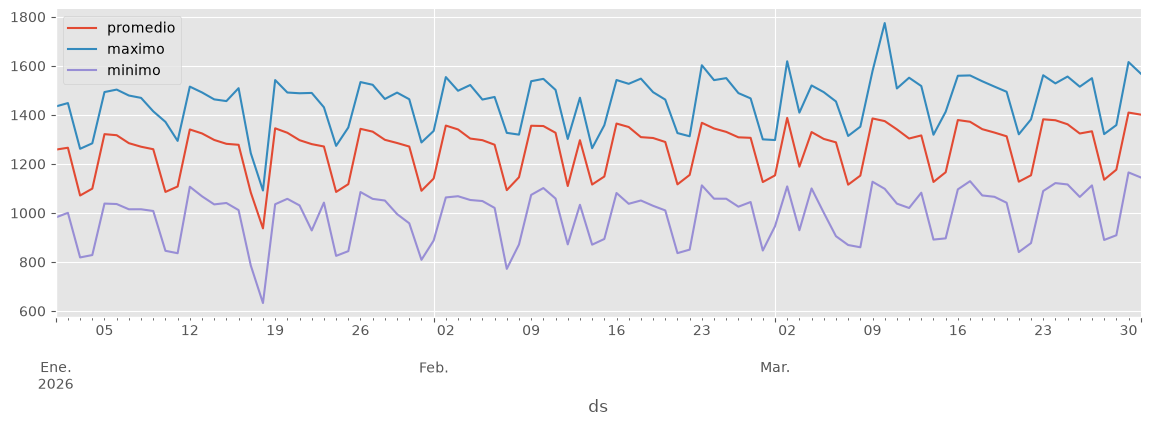

In [21]:
plt.figure(figsize=(14, 4))
# >>> COMPLETAR: graficar promedio, máximo y mínimo diario.

diario_promedio.plot(label= "promedio")
diario_maximo.plot(label = "maximo")
diario_minimo.plot(label = "minimo")
plt.legend()



### RESPONDER

1. ¿Qué información se pierde al pasar de horario a diario?
2. ¿Cuándo usarías promedio y cuándo máximo?
3. ¿Qué agregación usarías para demanda pico?

**Respuestas**








## Parte 5 - Rolling windows como herramienta exploratoria

Usamos ventanas móviles para suavizar la serie y resumir variabilidad reciente.


In [ ]:
rolling = pd.DataFrame(index=serie_horaria.index)
rolling["y"] = serie_horaria

# >>> COMPLETAR: calcular ventanas móviles exploratorias. Ver P0
rolling["media_24h"] = ????
rolling["media_168h"] = ?????
rolling["std_24h"] = ?????

plt.figure(figsize=(14, 4))
plt.plot(rolling.index, rolling["y"], label="Serie horaria", alpha=0.35)
# >>> COMPLETAR: graficar las dos medias móviles junto con la serie horaria.


In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(rolling.index, rolling["std_24h"], color="tab:red")
plt.title("Desvío móvil de 24 horas")
plt.xlabel("Fecha")
plt.ylabel("Desvío de demanda")
plt.show()

### DISCUTIR

1. ¿Qué ventana suaviza el patrón diario?
2. ¿Qué ocurre al principio de la serie?


**Respuestas**
  
    
      
        
        



## Parte 6 - Componentes: tendencia, estacionalidad y ruido

Nombramos componentes frecuentes de una serie para interpretar lo que vimos en los gráficos.

### RESPONDER

- ¿Qué parte se repite?
- ¿Qué parte cambia lentamente?
- ¿Qué parte parece ruido?
- ¿Los outliers deberían considerarse ruido?

**Respuestas**


  
   

    

     

      

       

        

## Parte 7 - Descomposición con statsmodels

Aplicamos una descomposición simple para separar tendencia, patrón estacional y residuo.


In [ ]:
# >>> COMPLETAR: elegir el período estacional diario.
periodo = 24

# >>> COMPLETAR: aplicar seasonal_decompose sobre serie_horaria.
descomposicion_24 = seasonal_decompose(serie_horaria, model="additive", period=periodo, extrapolate_trend="freq")

fig = descomposicion_24.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Descomposición aditiva con período {periodo}", y=1.02)
plt.show()

In [ ]:
# COMPLETAR
# Repetir la descomposición con patrón semanal.


### RESPONDER

1. ¿Qué período tiene sentido para patrón diario?
2. ¿Qué período tiene sentido para patrón semanal?
3. ¿Qué limitaciones tiene la descomposición?

**Respuestas**

  
    

     
      
       
        
         




## Parte 8. Descomposición MSTL 


#EXPERIMENTAR

Explorar el notebook de ejemplo  
https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/multipleseasonalities.html#multiple-seasonalities

Ver en dicho notebook cómo se realiza la descomposición MSTL y aplicarlo a la serie sintética.  


Descomponer la serie sintética considerando período estacional diario y semanal. Graficar la serie y sus componentes.



In [ ]:
models = [MSTL(
    season_length=[24, 24 * 7], # seasonalities of the time series
)]

In [ ]:
# COMPLETAR: 









## Parte 9 - Autocorrelación: ACF/PACF

Observamos dependencia temporal y detectamos lags candidatos para el práctico de features.

En esta etapa usamos ACF/PACF como herramientas exploratorias para detectar dependencia temporal y lags relevantes. En series con tendencia o fuerte estacionalidad, su interpretación para modelado requiere más cuidado.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# >>> COMPLETAR: ACF hasta 7 días de lags horarios.
plot_acf(serie_horaria, lags=24 * 7, ax=axes[0])
axes[0].set_title("ACF de demanda horaria hasta 7 días")
axes[0].set_xlabel("Lag horario")
axes[0].set_ylabel("Autocorrelación")
for lag in [1, 24, 168]:
    axes[0].axvline(lag, color="tab:red", linestyle="--", alpha=0.6)

# >>> COMPLETAR: PACF a nivel introductorio.
plot_pacf(serie_horaria, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("PACF de demanda horaria hasta 72 horas")
axes[1].set_xlabel("Lag horario")
axes[1].set_ylabel("Autocorrelación parcial")
plt.tight_layout()
plt.show()

### DISCUTIR

1. ¿Qué esperarías ver en lag 24?
2. ¿Qué esperarías ver en lag 168?
3. ¿Qué lags parecen candidatos para P2?

**Respuestas**


  
    
       

        
         
          
          